# Stars and Galaxies Dispersion Demo

This notebook demonstrates dispersing both **stars** and **galaxies** through the
Roman grism, producing a realistic simulated detector image with all three spectral
orders (0, 1, 2).

**What's in this notebook:**

| Component | Count | Spectra | Morphology |
|-----------|-------|---------|------------|
| Stars | 100 | G0V (Bruzual atlas), F158 mag 15–22 | Point sources (PSF only) |
| Galaxies | 100 | Kinney-Calzetti (KC96) templates at z=1.2–2.0, F158 mag 18–23 | Circular exponential, r_eff=0.3" |

**Key concepts demonstrated:**
1. Realistic stellar spectra via synphot
2. Galaxy spectra from KC96 atlas with cosmological redshifts
3. Wavelength-dependent PSFs from STPSF (trilinear interpolation)
4. **Jacobian-based morphology warping** for extended sources — the galaxy disperser
   warps the galaxy shape through the dispersion Jacobian before PSF convolution
5. Sensitivity curves for flux calibration across all orders
6. Efficient JAX `fori_loop` dispersion with JIT compilation

**Prerequisites:**
- PSF caches generated (`pixi run python scripts/generate_psf_caches.py`)
- See `notebooks/psf/multi_star_demo.ipynb` for the stars-only version
- See `notebooks/galaxy/jacobian_exploration.ipynb` for Jacobian analysis

In [ ]:
import os
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import AsinhNorm
from astropy.io import fits
import astropy.units as u
import jax
import jax.numpy as jnp

# Synphot for spectral templates and flux calibration
import synphot as syn
from roman_disperser import refdata

# Roman disperser modules
from roman_disperser.optical_model import RomanOpticalModel
import roman_disperser.optical_model_jax as omj
import roman_disperser.star_disperser as star_disperser
import roman_disperser.galaxy_disperser as galaxy_disperser
import roman_disperser.psf_model as psf_model
from roman_disperser import demo_utils

plt.rcParams['font.size'] = 11

---
## Configuration

All key parameters in one place. The wavelength grid uses 2\u00c5 spacing (5501 samples
from 0.9 to 2.0 \u03bcm), matching the star-only demo.

In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Source counts
N_STARS = 100
N_GALAXIES = 100

# Star magnitudes (F158 AB mag) — sampled from galacticus catalog
STAR_MAG_MIN = 15.0
STAR_MAG_MAX = 22.0

# Galaxy properties
GAL_MAG_MIN = 18.0       # F158 AB mag
GAL_MAG_MAX = 23.0
GAL_Z_MIN = 1.2          # Redshift range
GAL_Z_MAX = 2.0
GAL_REFF_ARCSEC = 0.3    # Half-light radius (circular exponential)
GAL_NPIX_NATIVE = 30     # Native pixels per side (3.3" at 0.11"/pix)
GAL_TEMPLATES = ['elliptical_template', 'starb1_template']

# Field boundaries (SCA coords, FITS 1-indexed, with margin from edges)
X_MIN, X_MAX = 100.0, 3988.0
Y_MIN, Y_MAX = 100.0, 3988.0

# Wavelength configuration
LAM_MIN, LAM_MAX = 0.9, 2.0   # microns
DLAM_ANGSTROMS = 2.0           # 2 Angstrom spacing

# Detector and orders
ORDERS = ['0', '1', '2']
DETECTOR = 'WFI05'
SCA = 5
PSF_CACHE_DIR = 'data/psf_cache'

# Visualization
ASINH_LINEAR_WIDTH = 0.01     # Asinh stretch parameter

# Reproducibility
RANDOM_SEED = 42

# Derived quantities
dlam_um = DLAM_ANGSTROMS / 1e4
n_wavelength = int((LAM_MAX - LAM_MIN) / dlam_um) + 1
OVERSAMPLE = 4  # Must match PSF payload

print(f"Configuration:")
print(f"  Stars:      {N_STARS} (mag {STAR_MAG_MIN}–{STAR_MAG_MAX})")
print(f"  Galaxies:   {N_GALAXIES} (mag {GAL_MAG_MIN}–{GAL_MAG_MAX}, z={GAL_Z_MIN}–{GAL_Z_MAX})")
print(f"  Galaxy morphology: circular exponential, r_eff={GAL_REFF_ARCSEC}\"")
print(f"  Galaxy image: {GAL_NPIX_NATIVE}×{GAL_NPIX_NATIVE} native → "
      f"{GAL_NPIX_NATIVE*OVERSAMPLE}×{GAL_NPIX_NATIVE*OVERSAMPLE} at {OVERSAMPLE}× oversampling")
print(f"  Wavelength: {LAM_MIN}–{LAM_MAX} μm, {DLAM_ANGSTROMS}Å spacing → {n_wavelength} samples")
print(f"  Orders: {ORDERS}")
print(f"  Detector: {DETECTOR} (SCA {SCA})")

Configuration:
  Stars:      100 (mag 15.0–22.0)
  Galaxies:   100 (mag 18.0–23.0, z=1.2–2.0)
  Galaxy morphology: circular exponential, r_eff=0.3"
  Galaxy image: 30×30 native → 120×120 at 4× oversampling
  Wavelength: 0.9–2.0 μm, 2.0Å spacing → 5501 samples
  Orders: ['0', '1', '2']
  Detector: WFI05 (SCA 5)


---
# Part 1: Wavelength Grid and Sensitivity Curves

The wavelength grid spans the full Roman grism bandpass (0.9–2.0 \u03bcm). The sensitivity
curves encode the instrument throughput for each spectral order — they convert
physical flux (FLAM) to detector counts via:

$$\text{counts} = F_\lambda \times \text{sensitivity} \times \Delta\lambda$$

In [3]:
# Create wavelength grid
wavelengths = np.linspace(LAM_MIN, LAM_MAX, n_wavelength, dtype=np.float32)
wavelengths_jax = jnp.array(wavelengths)
wavelengths_angstrom = wavelengths * 1e4  # For synphot (expects Angstroms)

dlam_angstroms = (wavelengths[1] - wavelengths[0]) * 1e4

print(f"Wavelength grid: {wavelengths[0]:.4f}–{wavelengths[-1]:.4f} μm, "
      f"Δλ = {dlam_angstroms:.2f} Å, N = {len(wavelengths)}")

Wavelength grid: 0.9000–2.0000 μm, Δλ = 2.00 Å, N = 5501


In [4]:
# Load grism sensitivity curves for each spectral order
project_root = Path(os.environ.get("PIXI_PROJECT_ROOT", "."))

sensitivity_files = {
    '1': project_root / 'data' / 'sensitivities' / 'SCA1_sens_12052024.fits',
    '0': project_root / 'data' / 'sensitivities' / 'SCA1_sens_12052024_order0.fits',
    '2': project_root / 'data' / 'sensitivities' / 'SCA1_sens_12052024_order2.fits',
}

sensitivities = {}
print("Loading sensitivity curves...")
for order, fpath in sensitivity_files.items():
    with fits.open(fpath) as hdul:
        wl_sens = hdul[1].data['WAVELENGTH'] / 1e4  # Å → μm
        sens_vals = hdul[1].data['SENSITIVITY']
        sens_interp = np.interp(wavelengths, wl_sens, sens_vals)
        sensitivities[order] = jnp.array(sens_interp.astype(np.float32))
        peak_idx = np.argmax(sens_interp)
        print(f"  Order {order}: peak = {sens_interp.max():.3e} at λ = {wavelengths[peak_idx]:.3f} μm")

Loading sensitivity curves...
  Order 1: peak = 1.415e+16 at λ = 1.482 μm
  Order 0: peak = 4.283e+14 at λ = 1.901 μm
  Order 2: peak = 2.104e+14 at λ = 1.003 μm


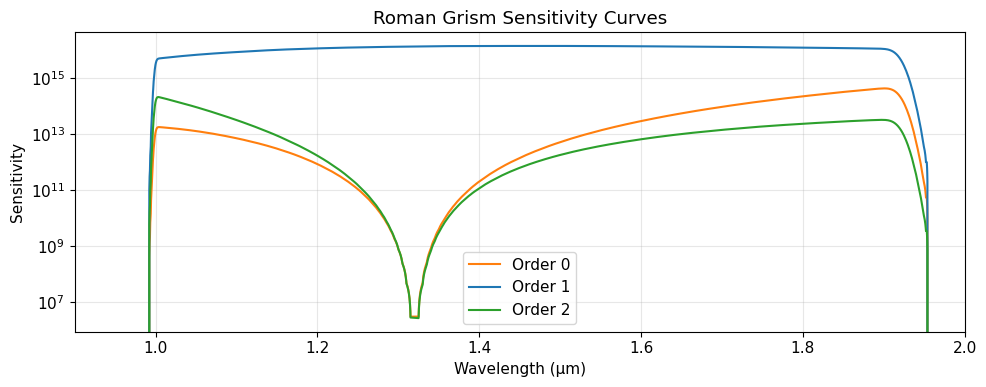

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = {'0': 'C1', '1': 'C0', '2': 'C2'}
for order in ORDERS:
    ax.semilogy(wavelengths, sensitivities[order],
                label=f'Order {order}', color=colors[order], lw=1.5)
ax.set(xlabel='Wavelength (μm)', ylabel='Sensitivity',
       title='Roman Grism Sensitivity Curves', xlim=(0.9, 2.0))
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

---
# Part 2: Stellar Spectra

We use the **G0V stellar template** from the Bruzual (1977) atlas, normalized to
F158 AB magnitudes. Magnitudes are sampled from a galacticus simulation catalog
that provides a realistic magnitude distribution.

In [ ]:
# Load G0V stellar template
star_template = refdata.get_template("g0v")
print(f"Stellar template: G0V (Bruzual atlas)")

# F158 bandpass for magnitude normalization
wfi_f158 = refdata.get_f158_band()
print(f"F158 pivot wavelength: {wfi_f158.pivot():.1f}")

In [7]:
# Load galacticus simulation catalog for realistic magnitude sampling
catalog_data = np.loadtxt(project_root / "data" / "stars" / "sim_star_cat_galacticus.txt",
                          skiprows=1)
catalog_magnitudes = catalog_data[:, 2]

# Random number generator — all random draws flow from this single seed
rng = np.random.default_rng(RANDOM_SEED)

# Sample star magnitudes from catalog
valid_mags = catalog_magnitudes[(catalog_magnitudes >= STAR_MAG_MIN) &
                                (catalog_magnitudes <= STAR_MAG_MAX)]
star_magnitudes = rng.choice(valid_mags, size=N_STARS, replace=False)

# Random star positions
star_x = rng.uniform(X_MIN, X_MAX, size=N_STARS).astype(np.float32)
star_y = rng.uniform(Y_MIN, Y_MAX, size=N_STARS).astype(np.float32)

# Generate normalized spectra for all stars
print(f"Generating {N_STARS} stellar spectra...")
t0 = time.time()

star_spectra_flam = np.zeros((N_STARS, n_wavelength), dtype=np.float32)
for i, mag in enumerate(star_magnitudes):
    norm_spec = star_template.normalize(mag * u.ABmag, band=wfi_f158)
    star_spectra_flam[i] = norm_spec(wavelengths_angstrom * u.AA,
                                      flux_unit=syn.units.FLAM).value

star_spectra_jax = jnp.array(star_spectra_flam)
star_x_jax = jnp.array(star_x)
star_y_jax = jnp.array(star_y)

print(f"  Done in {time.time()-t0:.1f}s")
print(f"  Magnitude range: {star_magnitudes.min():.1f}–{star_magnitudes.max():.1f} "
      f"(median {np.median(star_magnitudes):.1f})")

Generating 100 stellar spectra...
  Done in 0.5s
  Magnitude range: 15.5–22.0 (median 20.5)


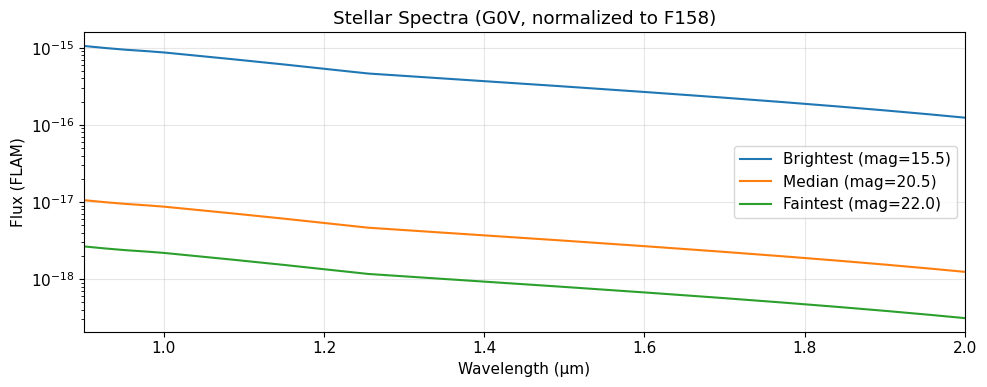

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
sort_idx = np.argsort(star_magnitudes)
for idx, label in [(sort_idx[0], 'Brightest'), (sort_idx[N_STARS//2], 'Median'),
                    (sort_idx[-1], 'Faintest')]:
    ax.semilogy(wavelengths, star_spectra_flam[idx],
                label=f'{label} (mag={star_magnitudes[idx]:.1f})', lw=1.5)
ax.set(xlabel='Wavelength (μm)', ylabel='Flux (FLAM)',
       title='Stellar Spectra (G0V, normalized to F158)', xlim=(0.9, 2.0))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Part 3: Galaxy Spectra

We use two spectral templates from the **Kinney-Calzetti (KC96) atlas**, which
provides empirical UV-optical spectral energy distributions for different galaxy types:

| Template | Description | Key features |
|----------|-------------|-------------|
| `elliptical_template` | Old stellar population | Red continuum, strong 4000Å break, no emission lines |
| `starb1_template` | Starburst galaxy | Blue continuum, strong emission lines (Hα, [OIII], [OII]) |

Each galaxy is assigned a random redshift z ∈ [1.2, 2.0]. At these redshifts,
prominent spectral features shift into the grism bandpass:
- **4000Å break**: observed at 0.88–1.2 μm (right at the blue edge)
- **[OIII] 5007Å**: observed at 1.10–1.50 μm (well centered in grism)
- **Hα 6563Å**: observed at 1.44–1.97 μm (spans most of the grism range)

The spectra are then normalized to F158 AB magnitudes in the range 18–23.

In [ ]:
# Load Kinney-Calzetti galaxy templates via refdata module
galaxy_templates = {}
_template_refdata_names = {
    'elliptical_template': 'kc96_elliptical',
    'starb1_template': 'kc96_starb1',
}
for name in GAL_TEMPLATES:
    galaxy_templates[name] = refdata.get_template(_template_refdata_names[name])
    wl_range = galaxy_templates[name].waveset
    print(f"  {name}: rest-frame {wl_range.min():.0f}–{wl_range.max():.0f}")

In [10]:
# Generate galaxy properties
# (The RNG continues from where the star draws left off, ensuring reproducibility)
galaxy_redshifts = rng.uniform(GAL_Z_MIN, GAL_Z_MAX, size=N_GALAXIES)
galaxy_magnitudes = rng.uniform(GAL_MAG_MIN, GAL_MAG_MAX, size=N_GALAXIES)
galaxy_template_names = rng.choice(GAL_TEMPLATES, size=N_GALAXIES)
galaxy_x = rng.uniform(X_MIN, X_MAX, size=N_GALAXIES).astype(np.float32)
galaxy_y = rng.uniform(Y_MIN, Y_MAX, size=N_GALAXIES).astype(np.float32)

# Summary
n_ell = np.sum(galaxy_template_names == 'elliptical_template')
n_sb = np.sum(galaxy_template_names == 'starb1_template')
print(f"Galaxy catalog: {N_GALAXIES} galaxies")
print(f"  Templates: {n_ell} elliptical, {n_sb} starburst")
print(f"  Redshift:  {galaxy_redshifts.min():.2f}–{galaxy_redshifts.max():.2f} "
      f"(median {np.median(galaxy_redshifts):.2f})")
print(f"  Magnitude: {galaxy_magnitudes.min():.1f}–{galaxy_magnitudes.max():.1f} "
      f"(median {np.median(galaxy_magnitudes):.1f})")

Galaxy catalog: 100 galaxies
  Templates: 46 elliptical, 54 starburst
  Redshift:  1.21–1.99 (median 1.63)
  Magnitude: 18.0–23.0 (median 20.7)


In [11]:
# Generate galaxy spectra: redshift template → normalize to F158 magnitude
print(f"Generating {N_GALAXIES} galaxy spectra...")
t0 = time.time()

galaxy_spectra_flam = np.zeros((N_GALAXIES, n_wavelength), dtype=np.float32)
for i in range(N_GALAXIES):
    template = galaxy_templates[galaxy_template_names[i]]
    spec_z = syn.SourceSpectrum(template.model, z=galaxy_redshifts[i])
    norm_spec = spec_z.normalize(galaxy_magnitudes[i] * u.ABmag, band=wfi_f158)
    galaxy_spectra_flam[i] = norm_spec(wavelengths_angstrom * u.AA,
                                        flux_unit=syn.units.FLAM).value

galaxy_spectra_jax = jnp.array(galaxy_spectra_flam)
galaxy_x_jax = jnp.array(galaxy_x)
galaxy_y_jax = jnp.array(galaxy_y)

print(f"  Done in {time.time()-t0:.1f}s")

Generating 100 galaxy spectra...
  Done in 0.7s


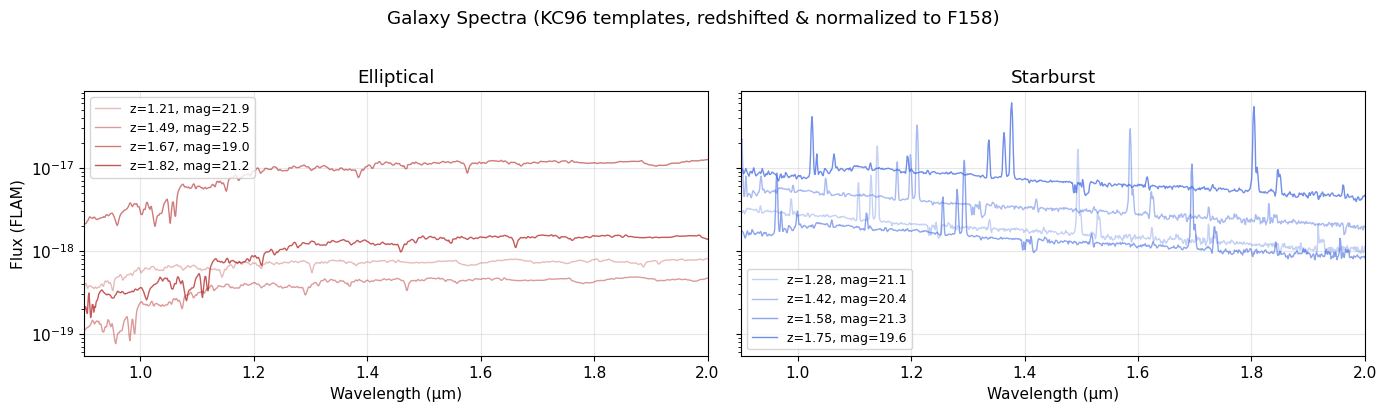

In [12]:
# Show a few example galaxy spectra, colored by template type
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

template_colors = {'elliptical_template': 'firebrick', 'starb1_template': 'royalblue'}
template_labels = {'elliptical_template': 'Elliptical', 'starb1_template': 'Starburst'}

for ax, tname in zip(axes, GAL_TEMPLATES):
    mask = galaxy_template_names == tname
    idxs = np.where(mask)[0]
    # Sort by redshift and show a few
    z_sorted = idxs[np.argsort(galaxy_redshifts[idxs])]
    for j, idx in enumerate(z_sorted[::len(z_sorted)//4][:4]):
        ax.semilogy(wavelengths, galaxy_spectra_flam[idx],
                     color=template_colors[tname], alpha=0.3 + 0.15*j, lw=1,
                     label=f'z={galaxy_redshifts[idx]:.2f}, mag={galaxy_magnitudes[idx]:.1f}')
    ax.set(xlabel='Wavelength (μm)', title=template_labels[tname], xlim=(0.9, 2.0))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Flux (FLAM)')
fig.suptitle('Galaxy Spectra (KC96 templates, redshifted & normalized to F158)', y=1.02)
plt.tight_layout()
plt.show()

---
# Part 4: Galaxy Morphology

All galaxies share the same circular exponential (Sérsic n=1) profile with
r_eff = 0.3". The image is created at **4× oversampling** to match the PSF payload,
giving a pixel scale of 0.0275"/pixel.

The galaxy disperser takes the galaxy **center position** as input (unlike the old
`disperser.py` which expected the image corner). Pixel spacing `dx = dy = 1/oversample`
is derived automatically from the PSF payload.

Galaxy image: (120, 120) pixels (4× oversampled)
  Physical size: 3.3" × 3.3"
  Pixel scale: 0.0275"/pix
  Total flux: 1.000000 (normalized)


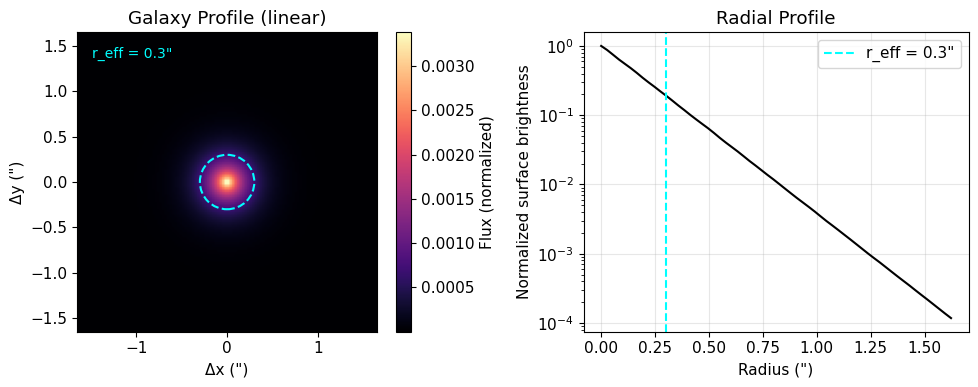

In [13]:
# Create the galaxy morphology template (shared by all galaxies)
galaxy_image = demo_utils.make_exponential_galaxy(
    npix=GAL_NPIX_NATIVE,
    half_light_radius_arcsec=GAL_REFF_ARCSEC,
    pixel_scale_arcsec=0.11,
    oversample=OVERSAMPLE,
    normalize=True,
)
galaxy_image_jax = jnp.array(np.array(galaxy_image, dtype=np.float32))

npix_os = GAL_NPIX_NATIVE * OVERSAMPLE
pix_scale_os = 0.11 / OVERSAMPLE

print(f"Galaxy image: {galaxy_image.shape} pixels ({OVERSAMPLE}× oversampled)")
print(f"  Physical size: {GAL_NPIX_NATIVE * 0.11:.1f}\" × {GAL_NPIX_NATIVE * 0.11:.1f}\"")
print(f"  Pixel scale: {pix_scale_os:.4f}\"/pix")
print(f"  Total flux: {float(galaxy_image.sum()):.6f} (normalized)")

# Visualize the galaxy morphology
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Linear scale
extent_arcsec = [-npix_os/2 * pix_scale_os, npix_os/2 * pix_scale_os,
                 -npix_os/2 * pix_scale_os, npix_os/2 * pix_scale_os]
im0 = axes[0].imshow(galaxy_image, origin='lower', extent=extent_arcsec, cmap='magma')
axes[0].set(xlabel='Δx (\")', ylabel='Δy (\")', title='Galaxy Profile (linear)')
circle = plt.Circle((0, 0), GAL_REFF_ARCSEC, fill=False, color='cyan', ls='--', lw=1.5)
axes[0].add_patch(circle)
axes[0].text(0.05, 0.95, f'r_eff = {GAL_REFF_ARCSEC}\"', transform=axes[0].transAxes,
             color='cyan', va='top', fontsize=10)
plt.colorbar(im0, ax=axes[0], label='Flux (normalized)')

# Log scale (radial profile)
center = (npix_os - 1) / 2
r_pix = np.arange(npix_os // 2)
r_arcsec = r_pix * pix_scale_os
# Azimuthal average
y, x = np.mgrid[0:npix_os, 0:npix_os]
r_grid = np.sqrt((x - center)**2 + (y - center)**2)
profile = np.array([float(galaxy_image[(r_grid >= r) & (r_grid < r+1)].mean())
                    for r in r_pix])
axes[1].semilogy(r_arcsec, profile / profile.max(), 'k-', lw=1.5)
axes[1].axvline(GAL_REFF_ARCSEC, color='cyan', ls='--', label=f'r_eff = {GAL_REFF_ARCSEC}\"')
axes[1].set(xlabel='Radius (\")', ylabel='Normalized surface brightness',
            title='Radial Profile')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Part 5: Load Model and Create Dispersers

We load:
1. The **optical model** — polynomial coefficients for spectral trace geometry
2. **PSF payloads** — precomputed PSF grids for trilinear interpolation
3. **Star dispersers** — point source dispersion (PSF deposition along trace)
4. **Galaxy dispersers** — extended source dispersion (Jacobian warping + PSF convolution)

The galaxy disperser is more expensive than the star disperser because it must:
- Compute the 2×2 Jacobian of the dispersion map at each PSF wavelength
- Warp the galaxy morphology through each Jacobian
- FFT-convolve with the wavelength-dependent PSF
- Then deposit onto the detector (same as star disperser)

In [14]:
# Load optical model
config_path = project_root / "data" / "Roman_grism_OpticalModel_v0.8.yaml"
model = RomanOpticalModel(config_file=str(config_path))

# Create optical payloads for each order
optical_payloads = {}
for order in ORDERS:
    optical_payloads[order] = omj.make_sca_payload(model, sca=SCA, order=order)

# Load PSF payloads from cache
cache_dir = project_root / PSF_CACHE_DIR
psf_payloads = {}

print("Loading PSF payloads...")
t0 = time.time()
for order in ['0', '1']:
    psf_payloads[order] = psf_model.get_or_make_psf_payload(
        detector=DETECTOR, order=order,
        cache_dir=str(cache_dir), verbose=True,
    )
    print(f"  Order {order}: {psf_payloads[order]['psf_grid'].shape}")

# Order 2 reuses Order 1 PSFs (same grism optical path)
psf_payloads['2'] = psf_payloads['1']
print(f"  Order 2: using Order 1 PSFs")
print(f"Loaded in {time.time()-t0:.1f}s")

Loading PSF payloads...
Loading PSF payload from cache: /Users/np274/10-Notebook/1-Projects/roman_disperser/data/psf_cache/psf_WFI05_GRISM0_4x4x56_0.90-2.00um_fov5.0_os4.npz
Loaded PSF cache: /Users/np274/10-Notebook/1-Projects/roman_disperser/data/psf_cache/psf_WFI05_GRISM0_4x4x56_0.90-2.00um_fov5.0_os4.npz
  Detector: WFI05, Order: 0
  Grid shape: (4, 4, 56, 184, 184)
  Memory: 121.3 MB
  Order 0: (4, 4, 56, 184, 184)
Loading PSF payload from cache: /Users/np274/10-Notebook/1-Projects/roman_disperser/data/psf_cache/psf_WFI05_GRISM1_4x4x56_0.90-2.00um_fov5.0_os4.npz
Loaded PSF cache: /Users/np274/10-Notebook/1-Projects/roman_disperser/data/psf_cache/psf_WFI05_GRISM1_4x4x56_0.90-2.00um_fov5.0_os4.npz
  Detector: WFI05, Order: 1
  Grid shape: (4, 4, 56, 184, 184)
  Memory: 121.3 MB
  Order 1: (4, 4, 56, 184, 184)
  Order 2: using Order 1 PSFs
Loaded in 1.9s


In [15]:
# Create star dispersers (one per order)
print("Creating dispersers...")
star_dispersers = {}
for order in ORDERS:
    star_dispersers[order] = star_disperser.make_star_disperser(
        psf_payloads[order], optical_payloads[order]
    )

# Create galaxy dispersers (one per order)
galaxy_dispersers = {}
for order in ORDERS:
    galaxy_dispersers[order] = galaxy_disperser.make_galaxy_disperser(
        psf_payloads[order], optical_payloads[order]
    )

print(f"  Created {len(ORDERS)} star dispersers + {len(ORDERS)} galaxy dispersers")

Creating dispersers...
  Created 3 star dispersers + 3 galaxy dispersers


## JIT Warmup

JAX compiles functions on their first call. We trigger this compilation now so
that the timed dispersion runs reflect pure execution time.

**Important:** The warmup inputs must have the **same array shapes** as the actual
computation — JAX recompiles when shapes change. The galaxy disperser compilation
is slower because it traces through the Jacobian computation, image warping, and
FFT convolution graph.

In [16]:
print("JIT warmup — compiling dispersers...")
warmup_output = jnp.zeros((4088, 4088), dtype=jnp.float32)

# Use actual shapes for warmup
warmup_star_flux = star_spectra_jax[0] * sensitivities['1'] * dlam_angstroms
warmup_gal_flux = galaxy_spectra_jax[0] * sensitivities['1'] * dlam_angstroms

t0 = time.time()

# Warm up star dispersers
for order in ORDERS:
    t1 = time.time()
    _ = star_dispersers[order](2000.0, 2000.0, wavelengths_jax,
                                warmup_star_flux, warmup_output)
    _.block_until_ready()
    print(f"  Star disperser order {order}: {time.time()-t1:.1f}s")

# Warm up galaxy dispersers
for order in ORDERS:
    t1 = time.time()
    _ = galaxy_dispersers[order](galaxy_image_jax, 2000.0, 2000.0,
                                  warmup_gal_flux, wavelengths_jax, warmup_output)
    _.block_until_ready()
    print(f"  Galaxy disperser order {order}: {time.time()-t1:.1f}s")

print(f"\nTotal warmup: {time.time()-t0:.1f}s")

JIT warmup — compiling dispersers...
  Star disperser order 0: 1.8s
  Star disperser order 1: 1.8s
  Star disperser order 2: 1.7s
  Galaxy disperser order 0: 3.3s
  Galaxy disperser order 1: 3.1s
  Galaxy disperser order 2: 3.0s

Total warmup: 14.8s


---
# Part 6: Disperse Stars

Each star is dispersed by:
1. Looking up the PSF at the star's (undispersed) detector position
2. Computing the dispersed position at each wavelength via the optical model
3. Depositing the PSF (scaled by flux) at each dispersed position

The `fori_loop` processes all stars sequentially, accumulating onto a single
output array. This avoids allocating N separate detector-sized arrays.

In [17]:
def disperse_all_stars_order(order, output):
    """Disperse all stars through one spectral order using fori_loop."""
    sens = sensitivities[order]
    disperser = star_dispersers[order]

    def body_fn(i, output):
        counts = star_spectra_jax[i] * sens * dlam_angstroms
        return disperser(star_x_jax[i], star_y_jax[i], wavelengths_jax, counts, output)

    return jax.lax.fori_loop(0, N_STARS, body_fn, output)


# Disperse all stars through all orders
print(f"Dispersing {N_STARS} stars × {len(ORDERS)} orders...")
output = jnp.zeros((4088, 4088), dtype=jnp.float32)

t0_total = time.time()
for order in ORDERS:
    t0 = time.time()
    output = disperse_all_stars_order(order, output)
    output.block_until_ready()
    elapsed = time.time() - t0
    print(f"  Order {order}: {elapsed:.1f}s ({elapsed/N_STARS:.2f}s/star)")

star_time = time.time() - t0_total
star_flux = float(output.sum())
print(f"\nStars complete: {star_time:.1f}s total, flux = {star_flux:.4e}")

Dispersing 100 stars × 3 orders...
  Order 0: 47.0s (0.47s/star)
  Order 1: 61.0s (0.61s/star)
  Order 2: 53.7s (0.54s/star)

Stars complete: 161.7s total, flux = 2.4783e+05


---
# Part 7: Disperse Galaxies

Galaxy dispersion is more computationally intensive than star dispersion.
For each galaxy at each wavelength, the disperser:

1. **Computes the Jacobian** of the SCA→SCA dispersion map at the galaxy center
2. **Warps the galaxy morphology** through the Jacobian (forward scatter, flux-conserving)
3. **Convolves** the warped image with the wavelength-dependent PSF (FFT)
4. **Deposits** the convolved image onto the detector at the exact dispersed position

Since all galaxies share the same morphology, the galaxy image is passed as a
constant while positions and spectra vary.

In [18]:
def disperse_all_galaxies_order(order, output):
    """Disperse all galaxies through one spectral order using fori_loop."""
    sens = sensitivities[order]
    disperser = galaxy_dispersers[order]

    def body_fn(i, output):
        counts = galaxy_spectra_jax[i] * sens * dlam_angstroms
        return disperser(galaxy_image_jax, galaxy_x_jax[i], galaxy_y_jax[i],
                         counts, wavelengths_jax, output)

    return jax.lax.fori_loop(0, N_GALAXIES, body_fn, output)


# Disperse all galaxies (accumulating onto the existing star output)
print(f"Dispersing {N_GALAXIES} galaxies × {len(ORDERS)} orders...")
print(f"(This is slower than stars due to Jacobian + convolution per galaxy)\n")

t0_total = time.time()
for order in ORDERS:
    t0 = time.time()
    output = disperse_all_galaxies_order(order, output)
    output.block_until_ready()
    elapsed = time.time() - t0
    print(f"  Order {order}: {elapsed:.1f}s ({elapsed/N_GALAXIES:.2f}s/galaxy)")

galaxy_time = time.time() - t0_total
total_flux = float(output.sum())
galaxy_flux = total_flux - star_flux
print(f"\nGalaxies complete: {galaxy_time:.1f}s total, flux = {galaxy_flux:.4e}")
print(f"Combined flux (stars + galaxies): {total_flux:.4e}")

Dispersing 100 galaxies × 3 orders...
(This is slower than stars due to Jacobian + convolution per galaxy)

  Order 0: 146.1s (1.46s/galaxy)
  Order 1: 187.6s (1.88s/galaxy)
  Order 2: 164.4s (1.64s/galaxy)

Galaxies complete: 498.1s total, flux = 6.6347e+04
Combined flux (stars + galaxies): 3.1418e+05


In [19]:
output_np = np.array(output)

print(f"Output image statistics:")
print(f"  Shape: {output_np.shape}")
print(f"  Total flux: {output_np.sum():.4e}")
print(f"  Peak: {output_np.max():.4e}")
print(f"  Non-zero pixels: {(output_np > 0).sum():,} ({100*(output_np > 0).sum()/output_np.size:.1f}%)")
print(f"\nTiming summary:")
print(f"  Stars:    {star_time:.1f}s ({star_time/N_STARS:.2f}s/star)")
print(f"  Galaxies: {galaxy_time:.1f}s ({galaxy_time/N_GALAXIES:.2f}s/galaxy)")
print(f"  Total:    {star_time + galaxy_time:.1f}s")

Output image statistics:
  Shape: (4088, 4088)
  Total flux: 3.1418e+05
  Peak: 3.7313e+01
  Non-zero pixels: 13,106,764 (78.4%)

Timing summary:
  Stars:    161.7s (1.62s/star)
  Galaxies: 498.1s (4.98s/galaxy)
  Total:    659.9s


---
# Part 8: Visualization

We use **asinh scaling** (the standard for astronomical imaging, used by SDSS).
The `linear_width` parameter sets the transition between linear and logarithmic
behavior — with `linear_width=0.01`, even faint galaxy traces become visible
alongside bright stellar spectra.

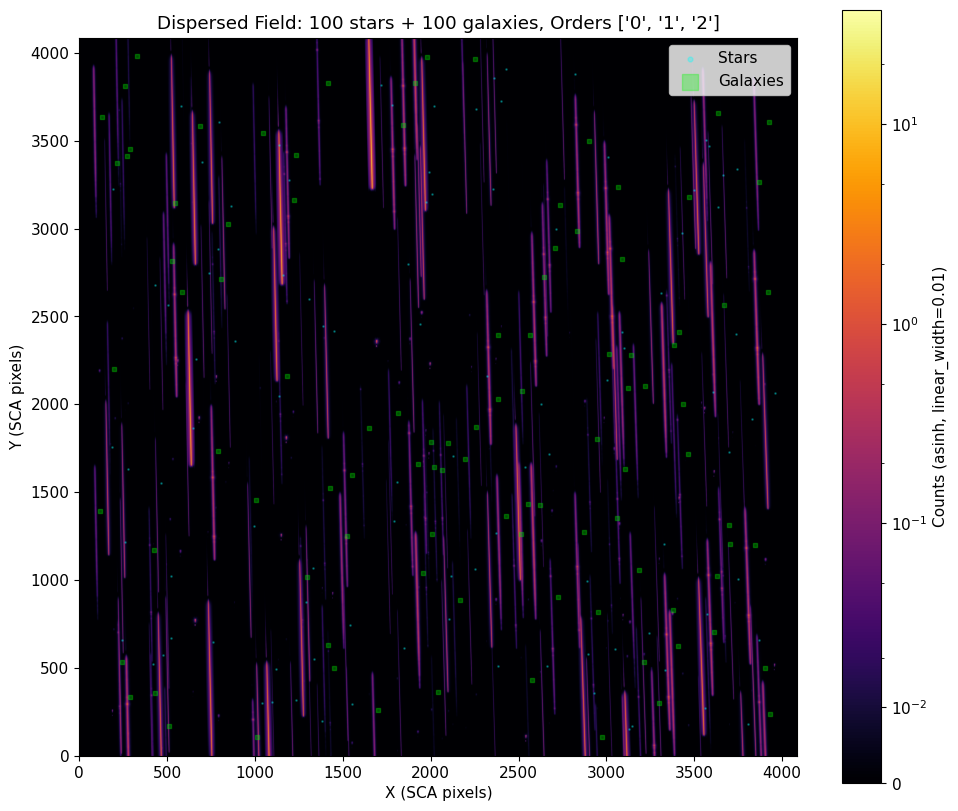

In [20]:
fig, ax = plt.subplots(figsize=(10, 10))

norm = AsinhNorm(linear_width=ASINH_LINEAR_WIDTH, vmin=0, vmax=output_np.max())
im = ax.imshow(output_np, origin='lower', cmap='inferno', norm=norm)

# Mark star positions
ax.scatter(star_x, star_y, s=3, c='cyan', alpha=0.3, marker='.', label='Stars')
# Mark galaxy positions
ax.scatter(galaxy_x, galaxy_y, s=8, c='lime', alpha=0.3, marker='s', label='Galaxies')

ax.set(xlabel='X (SCA pixels)', ylabel='Y (SCA pixels)',
       title=f'Dispersed Field: {N_STARS} stars + {N_GALAXIES} galaxies, Orders {ORDERS}')
ax.legend(loc='upper right', markerscale=4)
plt.colorbar(im, ax=ax, label=f'Counts (asinh, linear_width={ASINH_LINEAR_WIDTH})',
             shrink=0.8)
plt.tight_layout()
plt.show()

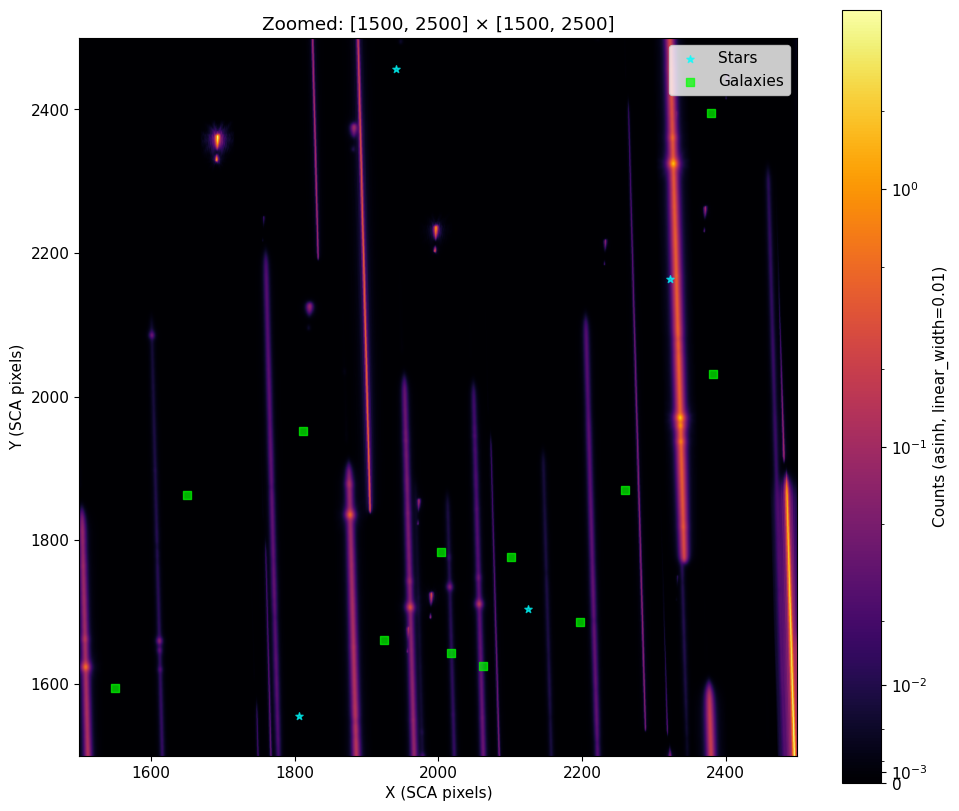

In [21]:
# Zoom into a central region to see individual traces
center_x, center_y = 2000, 2000
zoom_size = 500

x_lo = max(0, center_x - zoom_size)
x_hi = min(4088, center_x + zoom_size)
y_lo = max(0, center_y - zoom_size)
y_hi = min(4088, center_y + zoom_size)

zoomed = output_np[y_lo:y_hi, x_lo:x_hi]

fig, ax = plt.subplots(figsize=(10, 10))

# Stars and galaxies in this region
star_mask = ((star_x >= x_lo) & (star_x <= x_hi) &
             (star_y >= y_lo) & (star_y <= y_hi))
gal_mask = ((galaxy_x >= x_lo) & (galaxy_x <= x_hi) &
            (galaxy_y >= y_lo) & (galaxy_y <= y_hi))

norm = AsinhNorm(linear_width=ASINH_LINEAR_WIDTH, vmin=0, vmax=zoomed.max())
im = ax.imshow(zoomed, origin='lower', cmap='inferno',
               extent=[x_lo, x_hi, y_lo, y_hi], norm=norm)
ax.scatter(star_x[star_mask], star_y[star_mask],
           s=30, c='cyan', alpha=0.7, marker='*', label='Stars')
ax.scatter(galaxy_x[gal_mask], galaxy_y[gal_mask],
           s=30, c='lime', alpha=0.7, marker='s', label='Galaxies')
ax.set(xlabel='X (SCA pixels)', ylabel='Y (SCA pixels)',
       title=f'Zoomed: [{x_lo}, {x_hi}] × [{y_lo}, {y_hi}]')
ax.legend()
plt.colorbar(im, ax=ax, label=f'Counts (asinh, linear_width={ASINH_LINEAR_WIDTH})',
             shrink=0.8)
plt.tight_layout()
plt.show()

## Star vs Galaxy: Individual Comparison

To see the difference between point source and extended source dispersion, we
disperse the **brightest star** and **brightest galaxy** individually through
Order 1 and compare them side by side.

Key differences to look for:
- **Stars**: Sharp PSF features along the spectral trace
- **Galaxies**: Broader cross-dispersion profile due to the galaxy morphology
  being convolved with the PSF

Brightest star: mag=15.5, pos=(1717, 3815), total flux=3.883e+04
Brightest galaxy: mag=18.0, z=1.46, type=elliptical, pos=(1976, 3979), total flux=2.220e+03


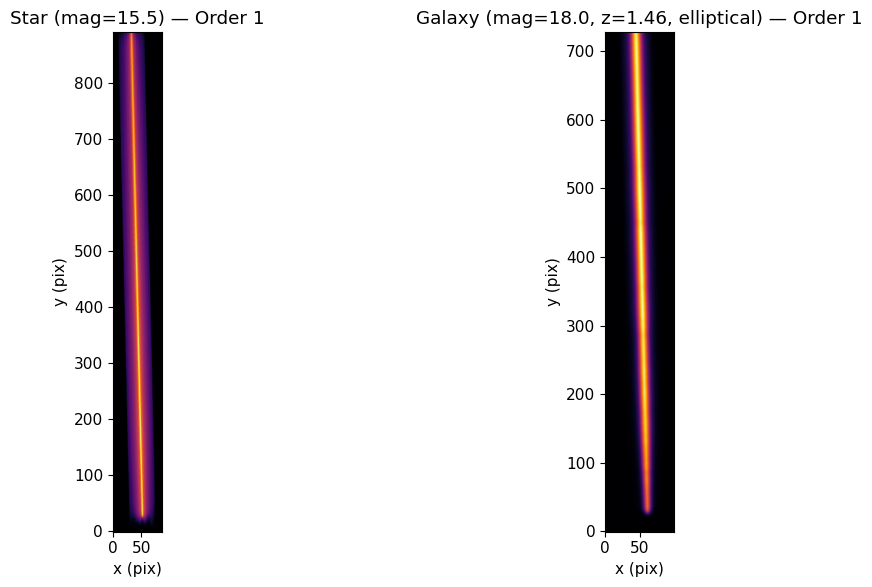

In [24]:
# Disperse brightest star individually (Order 1)
idx_star = np.argmin(star_magnitudes)
star_only = jnp.zeros((4088, 4088), dtype=jnp.float32)
star_counts = star_spectra_jax[idx_star] * sensitivities['1'] * dlam_angstroms
star_only = star_dispersers['1'](star_x_jax[idx_star], star_y_jax[idx_star],
                                  wavelengths_jax, star_counts, star_only)

# Disperse brightest galaxy individually (Order 1)
idx_gal = np.argmin(galaxy_magnitudes)
gal_only = jnp.zeros((4088, 4088), dtype=jnp.float32)
gal_counts = galaxy_spectra_jax[idx_gal] * sensitivities['1'] * dlam_angstroms
gal_only = galaxy_dispersers['1'](galaxy_image_jax,
                                   galaxy_x_jax[idx_gal], galaxy_y_jax[idx_gal],
                                   gal_counts, wavelengths_jax, gal_only)

# Find extent of each trace
star_np = np.array(star_only)
gal_np = np.array(gal_only)

star_extent = demo_utils.get_dispersed_extent(star_only, threshold_fraction=0.001)
gal_extent = demo_utils.get_dispersed_extent(gal_only, threshold_fraction=0.001)

# Add padding around each trace
pad = 20
star_cutout = star_np[max(0,star_extent[0]-pad):star_extent[1]+pad,
                       max(0,star_extent[2]-pad):star_extent[3]+pad]
gal_cutout = gal_np[max(0,gal_extent[0]-pad):gal_extent[1]+pad,
                     max(0,gal_extent[2]-pad):gal_extent[3]+pad]

print(f"Brightest star: mag={star_magnitudes[idx_star]:.1f}, "
      f"pos=({star_x[idx_star]:.0f}, {star_y[idx_star]:.0f}), "
      f"total flux={float(star_only.sum()):.3e}")
print(f"Brightest galaxy: mag={galaxy_magnitudes[idx_gal]:.1f}, "
      f"z={galaxy_redshifts[idx_gal]:.2f}, "
      f"type={galaxy_template_names[idx_gal].replace('_template','')}, "
      f"pos=({galaxy_x[idx_gal]:.0f}, {galaxy_y[idx_gal]:.0f}), "
      f"total flux={float(gal_only.sum()):.3e}")

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

norm_star = AsinhNorm(linear_width=ASINH_LINEAR_WIDTH, vmin=0, vmax=star_cutout.max())
axes[0].imshow(star_cutout, origin='lower', cmap='inferno', norm=norm_star)
axes[0].set_title(f'Star (mag={star_magnitudes[idx_star]:.1f}) — Order 1')
axes[0].set_xlabel('x (pix)')
axes[0].set_ylabel('y (pix)')

norm_gal = AsinhNorm(linear_width=ASINH_LINEAR_WIDTH, vmin=0, vmax=gal_cutout.max())
axes[1].imshow(gal_cutout, origin='lower', cmap='inferno', norm=norm_gal)
axes[1].set_title(f'Galaxy (mag={galaxy_magnitudes[idx_gal]:.1f}, z={galaxy_redshifts[idx_gal]:.2f}, '
                  f'{galaxy_template_names[idx_gal].replace("_template","")}) — Order 1')
axes[1].set_xlabel('x (pix)')
axes[1].set_ylabel('y (pix)')

plt.tight_layout()
plt.show()

---
# Summary

This notebook demonstrated the full workflow for simulating a Roman grism
observation with both stars and galaxies:

| Step | Stars | Galaxies |
|------|-------|----------|
| **Template** | G0V (Bruzual) | Elliptical & Starburst (KC96) |
| **Spectra** | Normalized to F158 | Redshifted z=1.2–2.0, normalized to F158 |
| **Morphology** | Point source | Circular exponential, r_eff=0.3" |
| **Disperser** | PSF deposition along trace | Jacobian warping + PSF convolution |
| **Orders** | 0, 1, 2 | 0, 1, 2 |

**Key technical points:**
- The **galaxy disperser** is more expensive than the star disperser because it
  must warp the galaxy morphology through the dispersion Jacobian and convolve
  with the PSF at each wavelength
- All dispersers use **wavelength chunking** (via `jax.lax.scan`) to keep memory
  bounded regardless of the number of wavelength samples
- The **closure pattern** captures payloads at JIT compile time, avoiding issues
  with non-traceable types in the payload dictionaries
- Cross-dispersion profiles clearly show the **morphological broadening** of
  galaxies compared to point-like stars

**Next steps:**
- Add noise (Poisson + read noise + dark current)
- Incorporate grism throughput efficiency curves
- Test with realistic galaxy morphologies (Sérsic profiles, irregular shapes)
- Scale to full detector simulations with 1000+ sources